<a href="https://www.kaggle.com/code/sonawanelalitsunil/cognitive-performance-insights-ml?scriptVersionId=233829294" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/human-cognitive-performance-analysis/human_cognitive_performance.csv


## Title: Cognitive Performance Insights

#### Description: Analyze and understand patterns in human cognitive performance through data-driven insights.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/human-cognitive-performance-analysis/human_cognitive_performance.csv')

In [3]:
df.head()

,User_ID,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score
0,U1,57,Female,6.5,3,Non-Vegetarian,6.5,Medium,41,583.33,65,36.71,39.77
1,U2,39,Female,7.6,9,Non-Vegetarian,10.8,High,214,368.24,58,54.35,57.68
2,U3,26,Male,8.2,6,Vegetarian,5.7,Low,429,445.21,49,32.57,29.54
3,U4,32,Male,7.8,9,Vegetarian,8.3,Low,464,286.33,94,70.15,74.59
4,U5,50,Male,9.7,2,Non-Vegetarian,11.3,Medium,365,237.65,62,87.54,91.78


In [4]:
df.tail()

,User_ID,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score
79995,U79996,55,Male,7.8,9,Non-Vegetarian,9.4,Low,157,312.34,55,50.80,46.49
79996,U79997,35,Female,9.8,6,Vegetarian,6.5,Medium,130,290.17,86,94.89,92.41
79997,U79998,32,Female,7.3,10,Non-Vegetarian,7.5,Low,462,249.57,72,63.51,67.35
79998,U79999,34,Male,8.7,8,Vegetarian,7.2,Medium,96,319.48,82,81.43,77.95
79999,U80000,41,Female,7.9,7,Vegetarian,2.0,Medium,27,263.21,42,80.39,84.45


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             80000 non-null  object 
 1   Age                 80000 non-null  int64  
 2   Gender              80000 non-null  object 
 3   Sleep_Duration      80000 non-null  float64
 4   Stress_Level        80000 non-null  int64  
 5   Diet_Type           80000 non-null  object 
 6   Daily_Screen_Time   80000 non-null  float64
 7   Exercise_Frequency  80000 non-null  object 
 8   Caffeine_Intake     80000 non-null  int64  
 9   Reaction_Time       80000 non-null  float64
 10  Memory_Test_Score   80000 non-null  int64  
 11  Cognitive_Score     80000 non-null  float64
 12  AI_Predicted_Score  80000 non-null  float64
dtypes: float64(5), int64(4), object(4)
memory usage: 7.9+ MB


In [6]:
df.describe()

,Age,Sleep_Duration,Stress_Level,Daily_Screen_Time,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,38.525525,7.005333,5.493762,6.504646,248.988213,399.973579,69.498350,58.172395,58.121357
std,12.101876,1.734435,2.865308,3.167072,144.541990,115.369329,17.305659,23.058522,23.119598
min,18.000000,4.000000,1.000000,1.000000,0.000000,200.000000,40.000000,0.000000,0.000000
25%,28.000000,5.500000,3.000000,3.800000,123.000000,300.150000,55.000000,40.910000,40.850000
50%,39.000000,7.000000,5.000000,6.500000,249.000000,400.360000,70.000000,58.360000,58.360000
75%,49.000000,8.500000,8.000000,9.200000,375.000000,499.250000,85.000000,75.830000,75.890000
max,59.000000,10.000000,10.000000,12.000000,499.000000,599.990000,99.000000,100.000000,100.000000


In [7]:
df.isnull().sum()

User_ID               0
Age                   0
Gender                0
Sleep_Duration        0
Stress_Level          0
Diet_Type             0
Daily_Screen_Time     0
Exercise_Frequency    0
Caffeine_Intake       0
Reaction_Time         0
Memory_Test_Score     0
Cognitive_Score       0
AI_Predicted_Score    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(80000, 13)

In [10]:
df.dtypes

User_ID                object
Age                     int64
Gender                 object
Sleep_Duration        float64
Stress_Level            int64
Diet_Type              object
Daily_Screen_Time     float64
Exercise_Frequency     object
Caffeine_Intake         int64
Reaction_Time         float64
Memory_Test_Score       int64
Cognitive_Score       float64
AI_Predicted_Score    float64
dtype: object

In [11]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Sleep_Duration', 'Stress_Level',
       'Diet_Type', 'Daily_Screen_Time', 'Exercise_Frequency',
       'Caffeine_Intake', 'Reaction_Time', 'Memory_Test_Score',
       'Cognitive_Score', 'AI_Predicted_Score'],
      dtype='object')

## Data visualizations

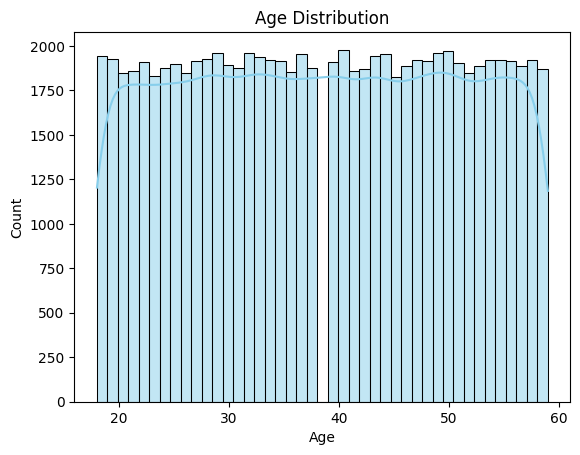

In [12]:
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

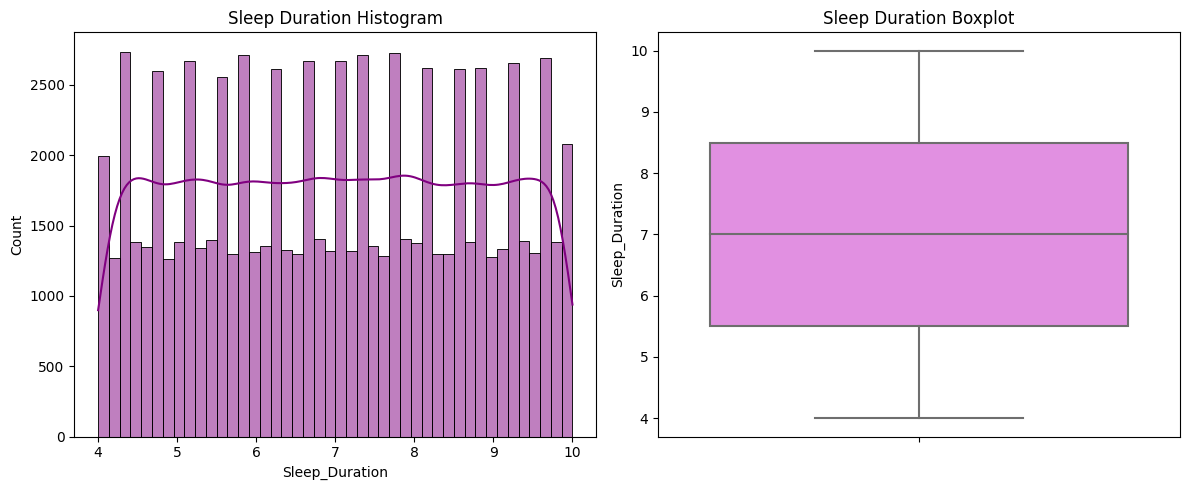

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['Sleep_Duration'], kde=True, ax=axs[0], color='purple')
axs[0].set_title("Sleep Duration Histogram")

sns.boxplot(y=df['Sleep_Duration'], ax=axs[1], color='violet')
axs[1].set_title("Sleep Duration Boxplot")
plt.tight_layout()
plt.show()


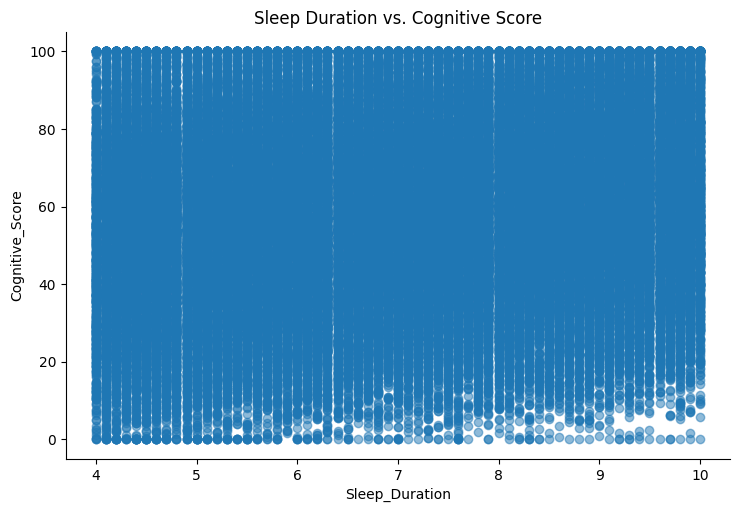

In [14]:
# Sleep Duration vs. Cognitive Score
sns.lmplot(x="Sleep_Duration", y="Cognitive_Score", data=df, aspect=1.5, scatter_kws={"alpha":0.5})
plt.title("Sleep Duration vs. Cognitive Score")
plt.show()

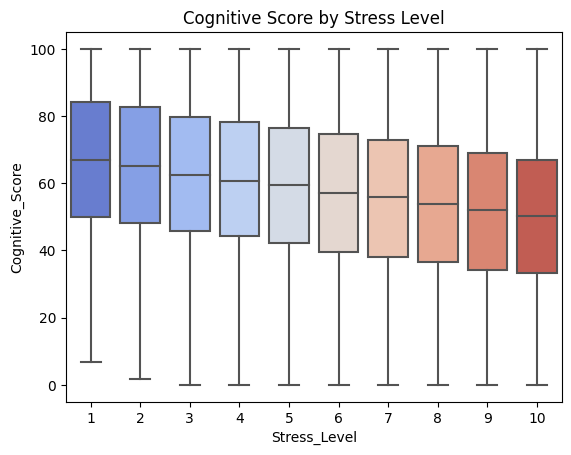

In [15]:
# Stress Level vs. Cognitive Score
sns.boxplot(x='Stress_Level', y='Cognitive_Score', data=df, palette="coolwarm")
plt.title("Cognitive Score by Stress Level")
plt.show()

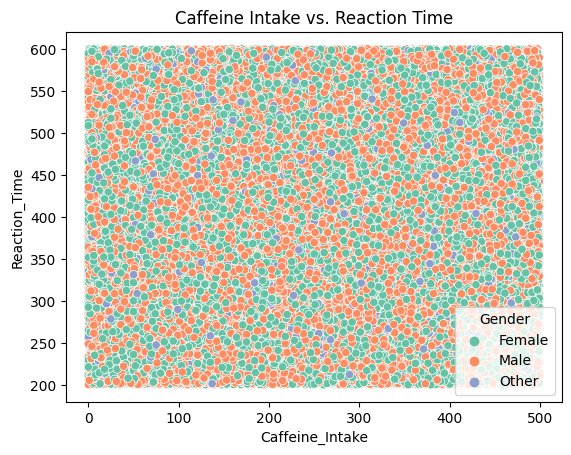

In [16]:
# Caffeine Intake vs. Reaction Time
sns.scatterplot(x='Caffeine_Intake', y='Reaction_Time', data=df, hue='Gender', palette='Set2')
plt.title("Caffeine Intake vs. Reaction Time")
plt.show()

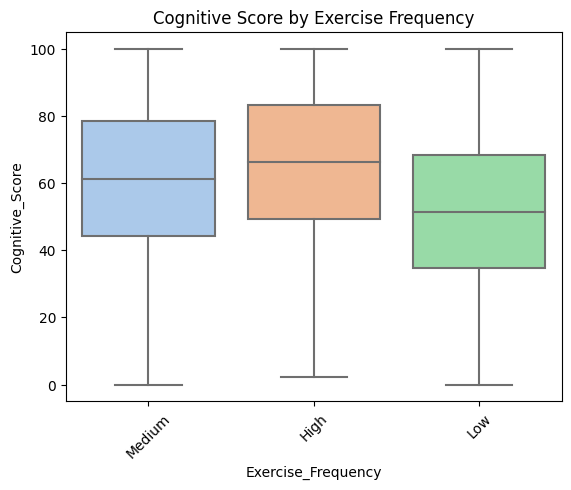

In [17]:
# Exercise Frequency vs. Cognitive Score
sns.boxplot(x='Exercise_Frequency', y='Cognitive_Score', data=df, palette='pastel')
plt.title("Cognitive Score by Exercise Frequency")
plt.xticks(rotation=45)
plt.show()

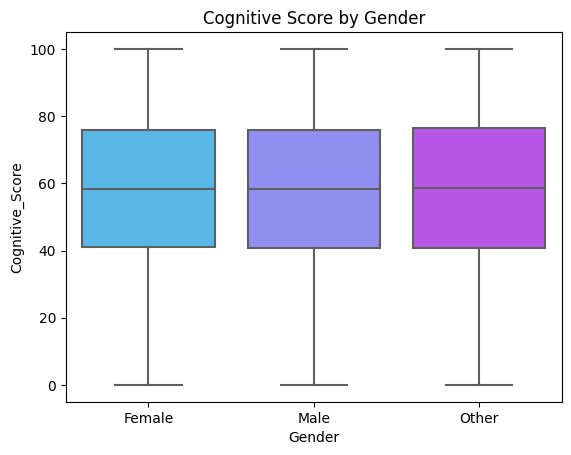

In [18]:
sns.boxplot(x='Gender', y='Cognitive_Score', data=df, palette='cool')
plt.title("Cognitive Score by Gender")
plt.show()

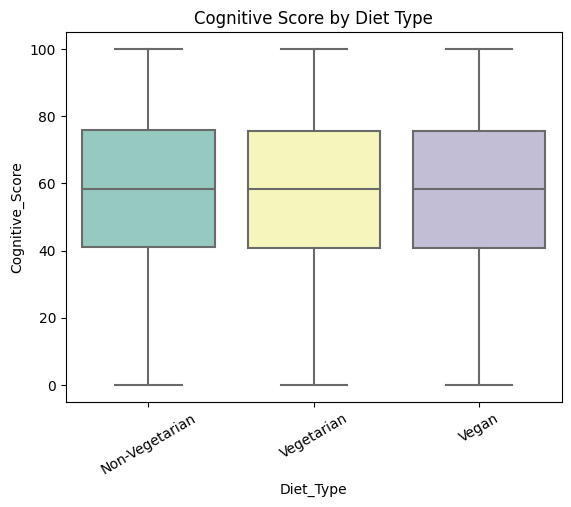

In [19]:
# Diet Type vs. Cognitive Score
sns.boxplot(x='Diet_Type', y='Cognitive_Score', data=df, palette='Set3')
plt.title("Cognitive Score by Diet Type")
plt.xticks(rotation=30)
plt.show()

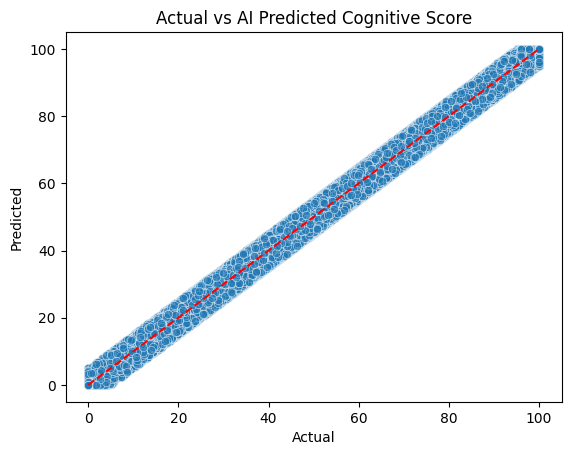

In [20]:
# Actual vs AI Predicted
sns.scatterplot(x='Cognitive_Score', y='AI_Predicted_Score', data=df, alpha=0.6)
plt.plot([df['Cognitive_Score'].min(), df['Cognitive_Score'].max()],
         [df['Cognitive_Score'].min(), df['Cognitive_Score'].max()],
         color='red', linestyle='--')
plt.title("Actual vs AI Predicted Cognitive Score")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

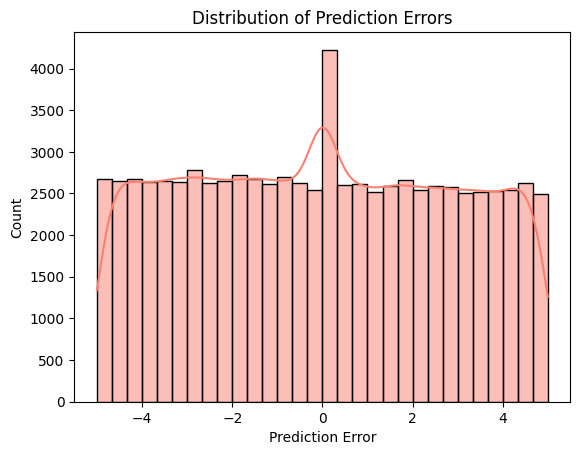

In [21]:
# Error Distribution
df['Prediction_Error'] = df['AI_Predicted_Score'] - df['Cognitive_Score']
sns.histplot(df['Prediction_Error'], bins=30, kde=True, color='salmon')
plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.show()

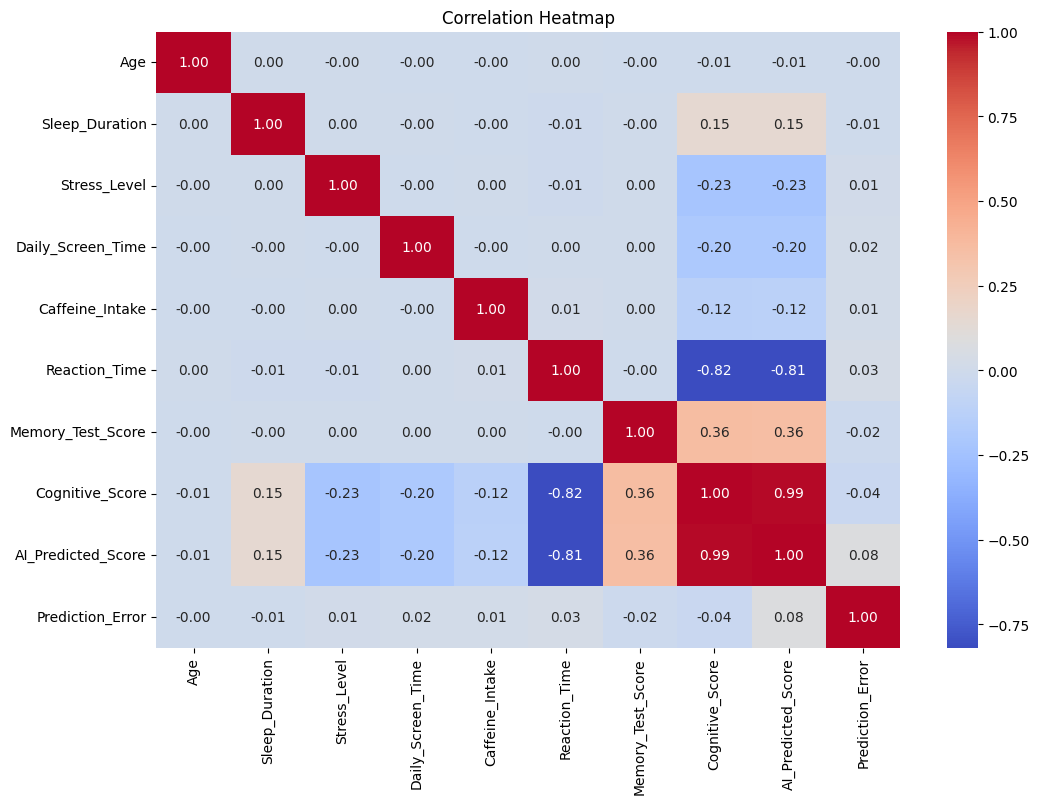

In [22]:
numeric_cols = df.select_dtypes(include='number')
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

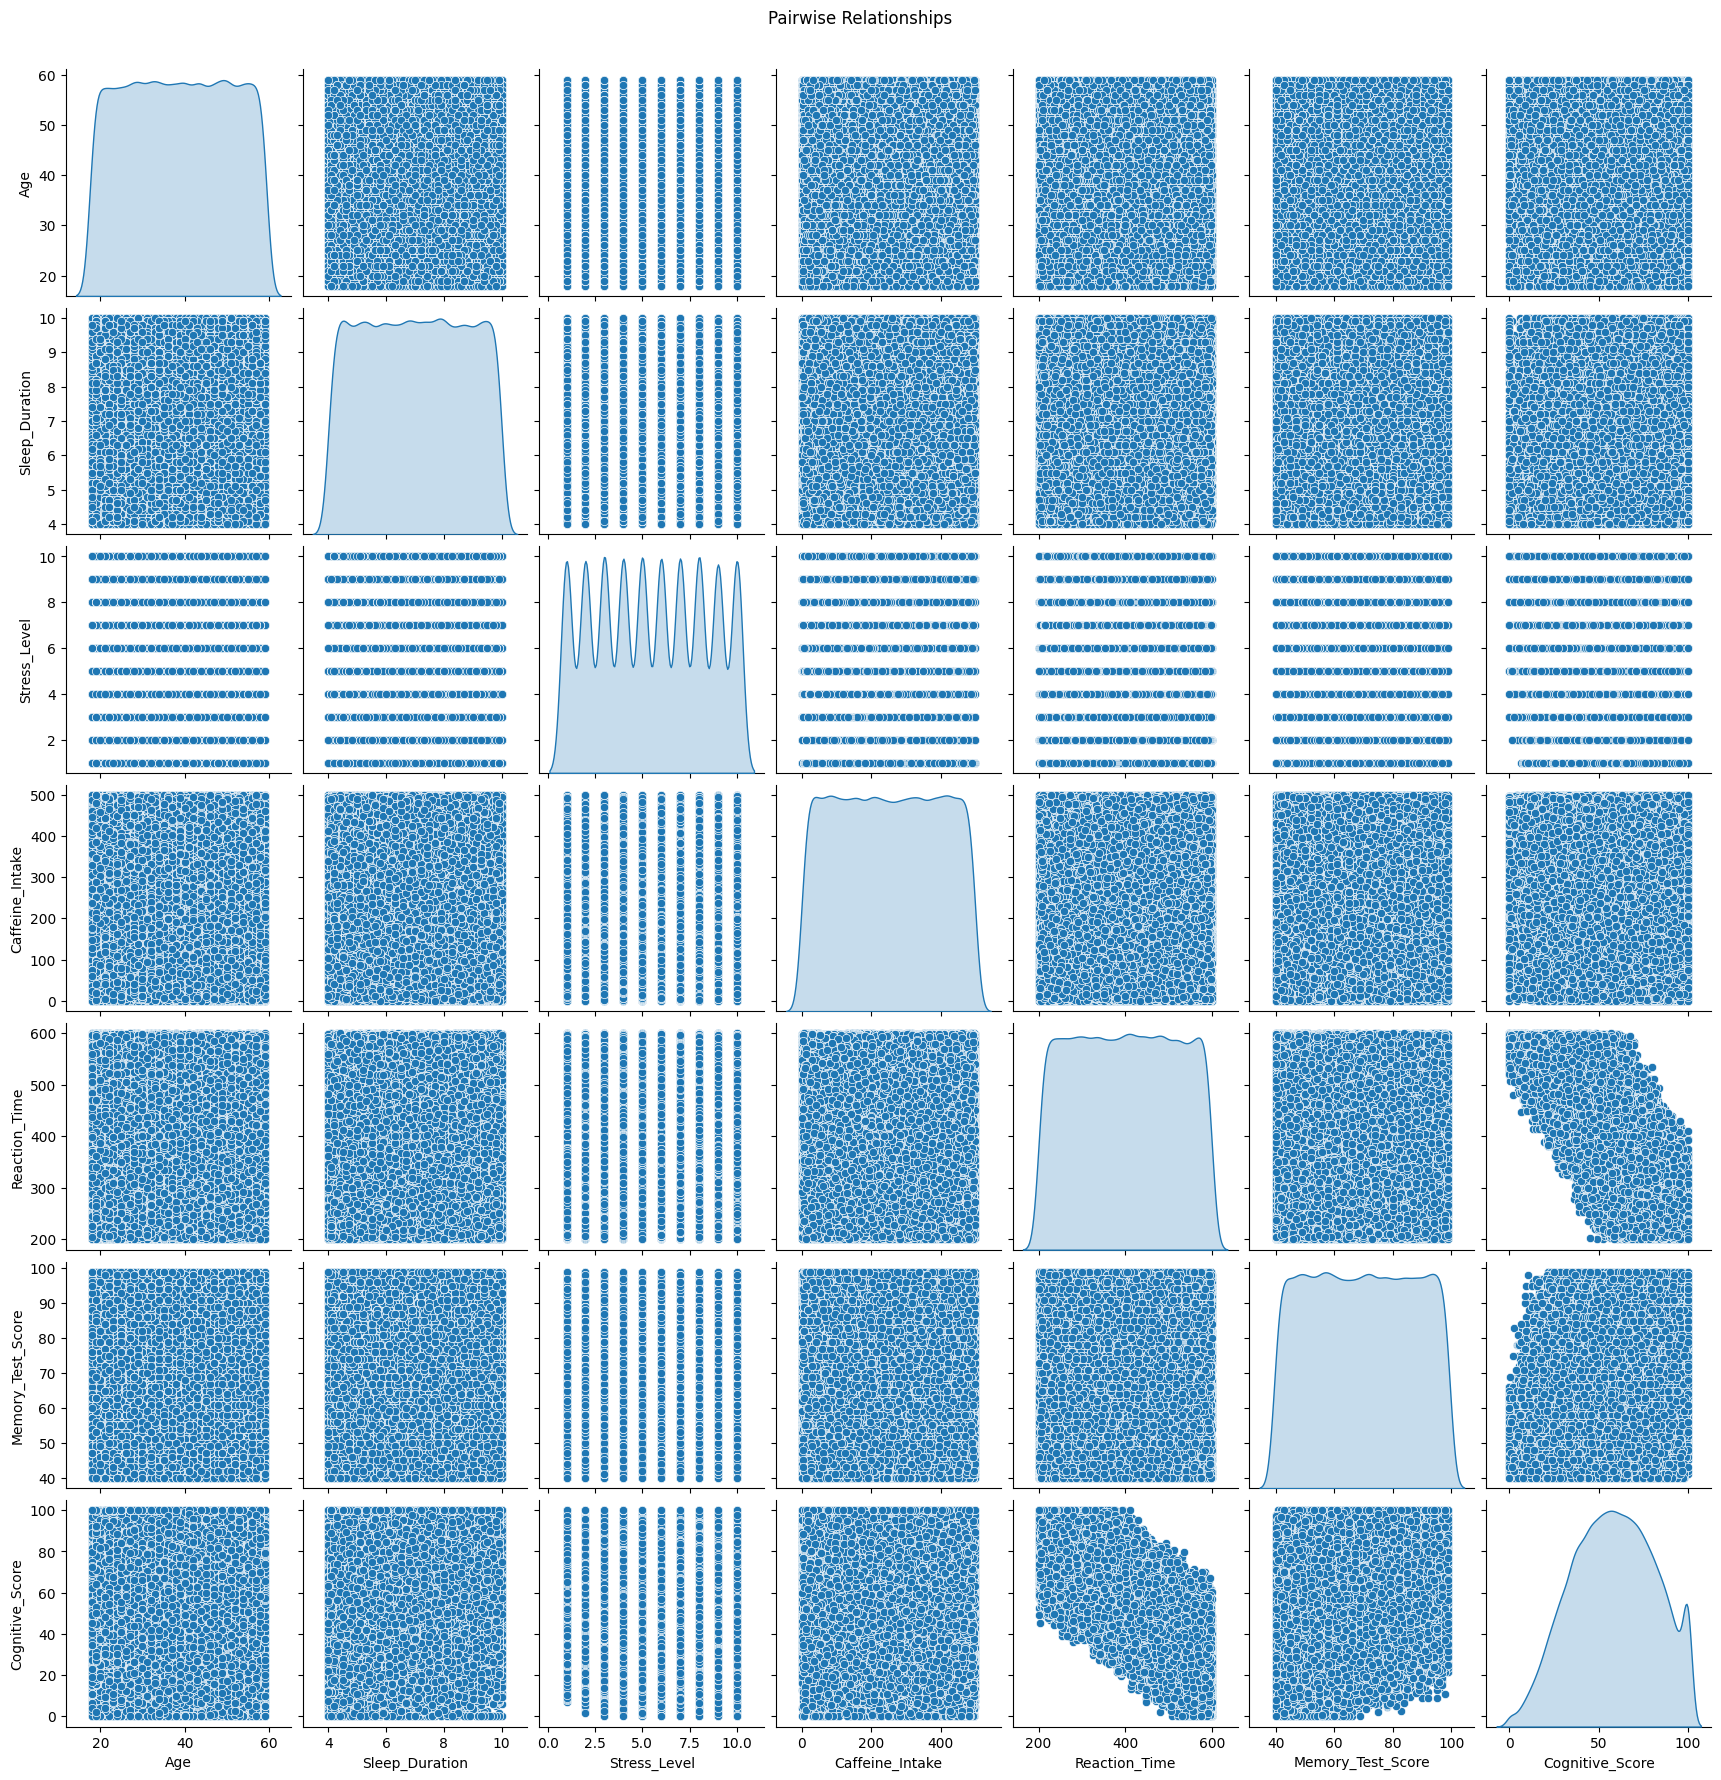

In [23]:
selected_cols = ['Age', 'Sleep_Duration', 'Stress_Level', 'Caffeine_Intake',
                 'Reaction_Time', 'Memory_Test_Score', 'Cognitive_Score']
sns.pairplot(df[selected_cols], diag_kind='kde')
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

## Predictive modeling

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [25]:
# Convert Cognitive_Score to categories: Low, Medium, High
df['Cognitive_Level'] = pd.qcut(df['Cognitive_Score'], q=3, labels=['Low', 'Medium', 'High'])

In [26]:
# Drop unused columns
df.drop(columns=['User_ID', 'Cognitive_Score', 'AI_Predicted_Score'], inplace=True)

In [27]:
# Label Encoding for categorical columns
label_cols = ['Gender', 'Diet_Type', 'Exercise_Frequency']
label_encoders = {}

for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [28]:
# Define features and target
X = df.drop(columns=['Cognitive_Level'])
y = df['Cognitive_Level']

In [29]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [30]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [31]:
# Train, predict and evaluate
accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = round(acc * 100, 2)


🔍 Naive Bayes - Accuracy: 78.62%


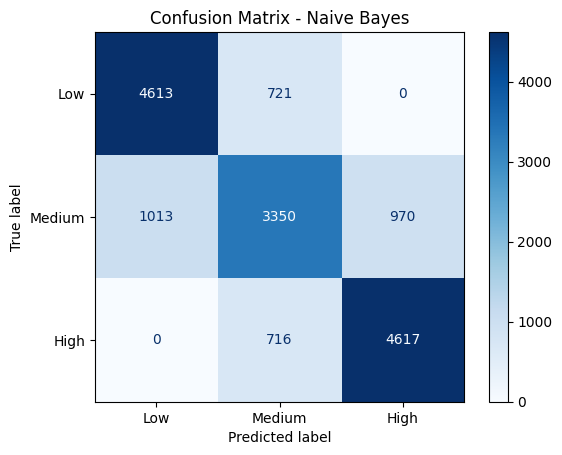

In [32]:
# Show Confusion Matrix
print(f"\n🔍 {name} - Accuracy: {round(acc*100, 2)}%")
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - {name}")
plt.show()


In [33]:
print("\n📊 Accuracy Summary:")
for name, acc in accuracy_results.items():
    print(f"{name}: {acc}%")


📊 Accuracy Summary:
Logistic Regression: 80.68%
Random Forest: 93.74%
Decision Tree: 87.13%
Support Vector Machine: 81.81%
K-Nearest Neighbors: 74.87%
Naive Bayes: 78.62%


## Thank you..pls upvote!!!!